In [1]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# STEP 2: LOAD DATA
df = pd.read_csv("responses.csv")

In [3]:
# STEP 3: DATA CLEANING
df = df.drop(columns=['Timestamp', 'Name'], errors='ignore')
df = df.dropna()

In [4]:
# STEP 4: CONVERT LIKERT SCALE TO NUMBERS
mapping = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

df = df.replace(mapping)

In [5]:
# STEP 5: KEEP ONLY NUMERIC DATA
df = df.select_dtypes(include='number')

In [6]:
# STEP 6: DESCRIPTIVE STATISTICS
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
       Chatbots respond faster to my queries compared to human agents.    \
count                                          17.000000                   
mean                                            3.941176                   
std                                             0.826936                   
min                                             2.000000                   
25%                                             4.000000                   
50%                                             4.000000                   
75%                                             4.000000                   
max                                             5.000000                   

       Chatbots save me time when resolving simple issues or getting information.    \
count                                          17.000000                              
mean                                            4.000000                              
std                           

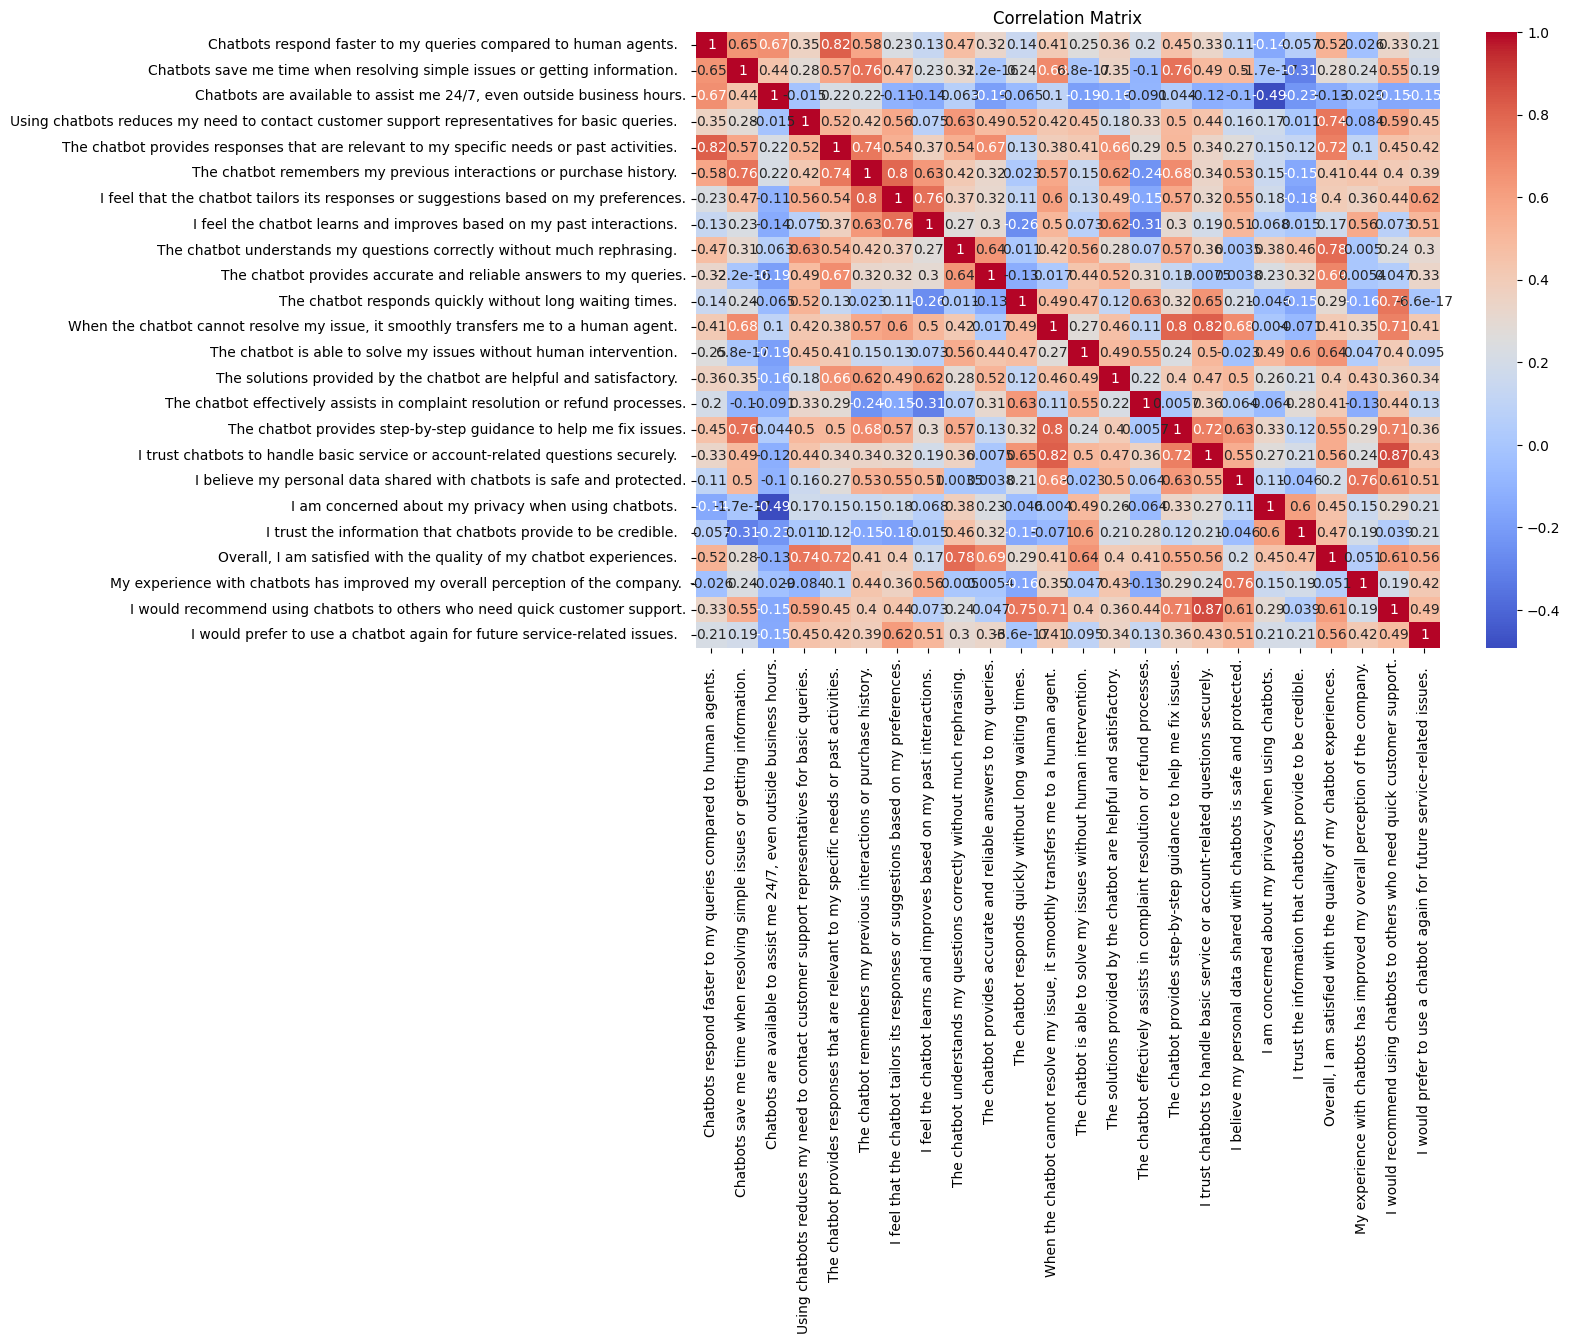

In [7]:
# STEP 7: CORRELATION HEATMAP
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
# STEP 8: REGRESSION ANALYSIS
y = df['Overall, I am satisfied with the quality of my chatbot experiences.  ']
X = df.drop(columns=['Overall, I am satisfied with the quality of my chatbot experiences.  '])

X = sm.add_constant(X)

In [9]:
model = sm.OLS(y, X).fit()